# Food Security Assessment

This notebook runs the `food_security` module for an approximate Marsabit County
AOI. It combines vegetation condition, temperature stress, rainfall anomaly,
NDVI trend, surface water, terrain, and land cover to classify food-security risk.


## Before you run

Use at least one complete growing season. A multi-year period gives the vegetation
and rainfall time series more context. The example uses 1 km sampling to match the
coarser MODIS and CHIRPS inputs.


In [1]:
from dataclasses import asdict
from pathlib import Path
import os

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
from dotenv import load_dotenv

from climate_change import USE_CASE_REGISTRY, run_analysis

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

GEE_PROJECT = os.environ.get("GEE_PROJECT", "").strip()
if not GEE_PROJECT:
    raise RuntimeError(
        "Set GEE_PROJECT in your shell or in the repository .env file before running this notebook."
    )

OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = PROJECT_ROOT / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

In [2]:
module_info = USE_CASE_REGISTRY["food_security"]
print(module_info.name)
print(module_info.date_guidance)
print("Models:", [option.id for option in module_info.model_options])

Food Security Assessment
Select a full growing season (at least 3 months). Long rains: Mar–May. Short rains: Oct–Dec.
Models: ['rf', 'xgboost', 'ensemble']


In [3]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [36.00, 1.00],
            [38.20, 1.00],
            [38.20, 3.70],
            [36.00, 3.70],
            [36.00, 1.00],
        ]
    ],
}

analysis_args = {
    "module": "food_security",
    "aoi_geojson": aoi,
    "start_date": "2018-01-01",
    "end_date": "2023-12-31",
    "country": "Kenya",
    "gee_project": GEE_PROJECT,
    "extra_params": {
        "model_type": "rf",  # "rf", "xgboost", or "ensemble"
        "lt_baseline_start": "2001-01-01",
        "s2_start": "2020-01-01",
        "n_pixels": 3000,
        "scale": 1000,
        "output_dir": str(OUTPUT_DIR),
        "prefix": "marsabit_food_security",
    },
}

In [4]:
output = await run_analysis(**analysis_args)

2026-06-24 13:58:19,407 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
/home/odero-george/workspace/climate-change/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37805 instead
  warnings.warn(
2026-06-24 13:58:19,427 - distributed.scheduler - INFO - State start
2026-06-24 13:58:19,431 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:33611
2026-06-24 13:58:19,431 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:37805/status
2026-06-24 13:58:19,432 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-06-24 13:58:19,442 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38895'
2026-06-24 13:58:19,444 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34479'
2

In [5]:
print("Module:", output.module)
print("Raster output:", output.raster_path)
print("GeoJSON features:", len(output.geojson.get("features", [])))
print("Chart keys:", sorted(output.charts))
print("Metadata:", output.metadata)
output.stats

Module: food_security
Raster output: {'food_security_risk': '/home/odero-george/workspace/climate-change/outputs/marsabit_food_security_food_security_risk.tif'}
GeoJSON features: 3891
Chart keys: ['indices', 'model_performance', 'riskDist', 'shap', 'timeSeries']
Metadata: {'model': 'rf', 'country': 'Kenya', 'start_date': '2018-01-01', 'end_date': '2023-12-31', 'raster': {'food_security_risk': '/home/odero-george/workspace/climate-change/outputs/marsabit_food_security_food_security_risk.tif'}, 'spatial_resolution_m': 1000, 'n_pixels_sampled': 3000}


{'model_type': 'rf',
 'n_pixels_sampled': 3000,
 'rf_cv_f1': 0.9538,
 'rf_f1': 0.9651,
 'rf_accuracy': 0.965,
 'xgb_cv_f1': 0.9617,
 'xgb_f1': 0.9717,
 'xgb_accuracy': 0.9717,
 'ensemble_f1': 0.97,
 'selected_f1': 0.9651,
 'high_risk_pct': 33.6,
 'top_driver': 'vci',
 'vci_mean': 31.0,
 'tci_mean': 53.1,
 'vhi_mean': 42.0,
 'analysed_pixels': 73444,
 'low_risk_pct': 32.6,
 'medium_risk_pct': 33.8,
 'total_area_ha': 7305844.8,
 'country': 'Kenya'}

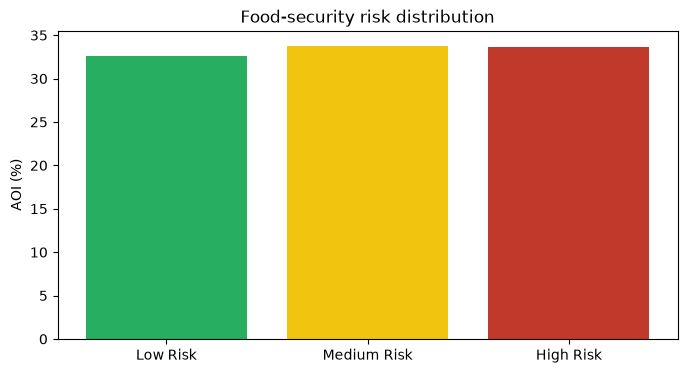

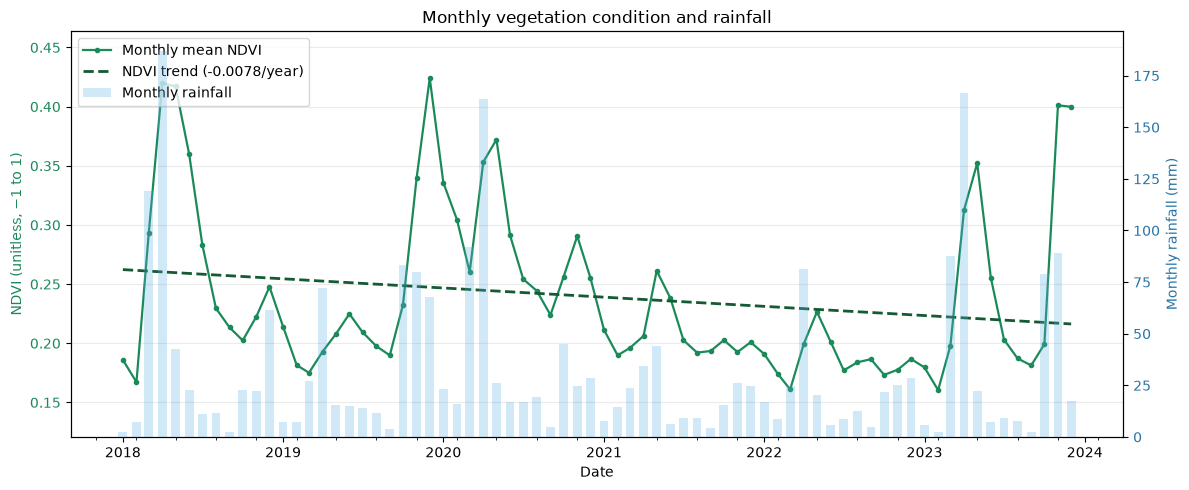

In [6]:
risk = output.charts.get("riskDist", {})
if risk.get("labels"):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(risk["labels"], risk["data"], color=["#27AE60", "#F1C40F", "#C0392B"])
    ax.set_ylabel("AOI (%)")
    ax.set_title("Food-security risk distribution")
    plt.show()

series = output.charts.get("timeSeries", {})
if series.get("labels"):
    import matplotlib.dates as mdates
    import numpy as np
    import pandas as pd

    dates = pd.to_datetime(series["labels"], format="%Y-%m")
    datasets = {item["label"]: item["data"] for item in series.get("datasets", [])}
    ndvi = np.asarray(datasets.get("NDVI", []), dtype=float)
    rainfall = np.asarray(datasets.get("Monthly rain (mm)", []), dtype=float)

    fig, ndvi_ax = plt.subplots(figsize=(12, 5))
    rain_ax = ndvi_ax.twinx()

    if ndvi.size:
        ndvi_ax.plot(
            dates,
            ndvi,
            color="#1B8A5A",
            marker="o",
            markersize=3,
            linewidth=1.6,
            label="Monthly mean NDVI",
            zorder=3,
        )
        valid = np.isfinite(ndvi)
        if valid.sum() >= 2:
            month_number = np.arange(len(dates), dtype=float)
            slope, intercept = np.polyfit(month_number[valid], ndvi[valid], 1)
            trend = intercept + slope * month_number
            ndvi_ax.plot(
                dates,
                trend,
                color="#145A32",
                linestyle="--",
                linewidth=2,
                label=f"NDVI trend ({slope * 12:+.4f}/year)",
                zorder=4,
            )

        finite_ndvi = ndvi[np.isfinite(ndvi)]
        if finite_ndvi.size:
            padding = max(0.03, float(np.ptp(finite_ndvi)) * 0.15)
            ndvi_ax.set_ylim(
                max(-1.0, float(finite_ndvi.min()) - padding),
                min(1.0, float(finite_ndvi.max()) + padding),
            )

    if rainfall.size:
        rain_ax.bar(
            dates,
            rainfall,
            width=20,
            color="#5DADE2",
            alpha=0.28,
            label="Monthly rainfall",
            zorder=1,
        )

    ndvi_ax.set_title("Monthly vegetation condition and rainfall")
    ndvi_ax.set_xlabel("Date")
    ndvi_ax.set_ylabel("NDVI (unitless, −1 to 1)", color="#1B8A5A")
    rain_ax.set_ylabel("Monthly rainfall (mm)", color="#2874A6")
    ndvi_ax.tick_params(axis="y", labelcolor="#1B8A5A")
    rain_ax.tick_params(axis="y", labelcolor="#2874A6")
    ndvi_ax.xaxis.set_major_locator(mdates.YearLocator())
    ndvi_ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ndvi_ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
    ndvi_ax.grid(axis="y", alpha=0.25)

    handles_1, labels_1 = ndvi_ax.get_legend_handles_labels()
    handles_2, labels_2 = rain_ax.get_legend_handles_labels()
    ndvi_ax.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper left")
    fig.tight_layout()
    plt.show()

In [7]:
# Optional: generate a PDF report in a second call.
# Set this to True only when you want the extra analysis/report run.
GENERATE_REPORT = False

if GENERATE_REPORT:
    report_output = await run_analysis(
        **analysis_args,
        report_output_dir=str(REPORT_DIR),
    )
    print("Report:", report_output.metadata.get("report_path"))

Report: /home/odero-george/workspace/climate-change/reports/food_security_20260624_110015.pdf
